# (Train / Val / Test Split)

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Ensure working directory is project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(f"Current Working Directory: {os.getcwd()}")

# Load Artifact 2
input_artifact = 'artifacts/data/02_labeled_orders.parquet'
assert os.path.exists(input_artifact), f" Artifact not found: {input_artifact}"

df = pd.read_parquet(input_artifact)
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
print(f" Loaded Labeled Artifact successfully: {df.shape[0]:,} rows, {df.shape[1]} columns.")


Current Working Directory: c:\Users\rosto\OneDrive\سطح المكتب\مشروع mlops
 Loaded Labeled Artifact successfully: 96,470 rows, 43 columns.


## 2. Temporal Analysis

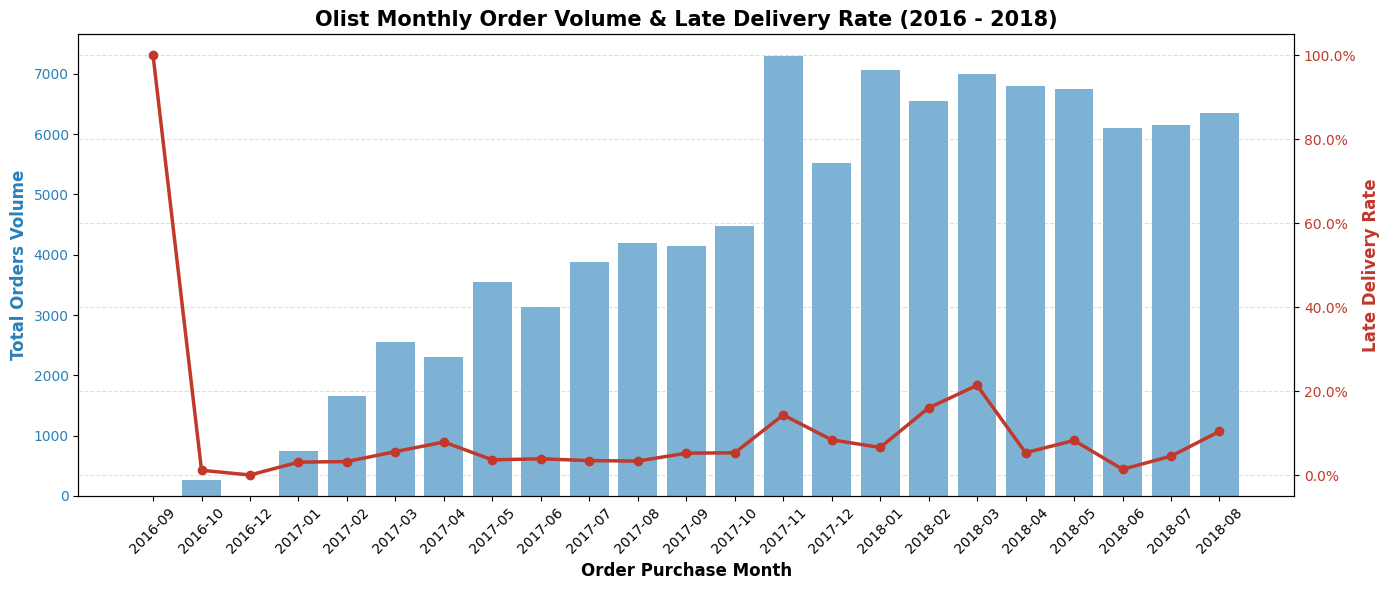

Chart saved to: artifacts/figures/temporal_drift_trend.png


In [3]:
# Add year-month column for temporal analysis
df['purchase_year_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# Group by month
monthly_stats = df.groupby('purchase_year_month').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    late_rate=('is_late', 'mean')
).reset_index()

monthly_stats['purchase_year_month_str'] = monthly_stats['purchase_year_month'].astype(str)

# Plot monthly volume and late rate
fig, ax1 = plt.subplots(figsize=(14, 6))

color = '#2980b9'
ax1.set_xlabel('Order Purchase Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Orders Volume', color=color, fontsize=12, fontweight='bold')
bars = ax1.bar(monthly_stats['purchase_year_month_str'], monthly_stats['total_orders'], color=color, alpha=0.6, label='Order Volume')
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()  
color = '#c0392b'
ax2.set_ylabel('Late Delivery Rate', color=color, fontsize=12, fontweight='bold')
line = ax2.plot(monthly_stats['purchase_year_month_str'], monthly_stats['late_rate'], color=color, marker='o', linewidth=2.5, label='Late Rate')
ax2.tick_params(axis='y', labelcolor=color)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

plt.title('Olist Monthly Order Volume & Late Delivery Rate (2016 - 2018)', fontsize=15, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()

trend_fig_path = 'artifacts/figures/temporal_drift_trend.png'
plt.savefig(trend_fig_path, dpi=300)
plt.show()
print(f"Chart saved to: {trend_fig_path}")


## 3. Executing Temporal Split
  - **(Train):**  70% 
  - **(Validation):**  15% 
  - **(Test):**  15% 


In [4]:
# Sort dataset chronologically by purchase timestamp
df_sorted = df.sort_values(by='order_purchase_timestamp').reset_index(drop=True)

total_rows = len(df_sorted)
train_cutoff_idx = int(total_rows * 0.70)
val_cutoff_idx = int(total_rows * 0.85)

train_df = df_sorted.iloc[:train_cutoff_idx].copy()
val_df = df_sorted.iloc[train_cutoff_idx:val_cutoff_idx].copy()
test_df = df_sorted.iloc[val_cutoff_idx:].copy()

print(f"Total Rows: {total_rows:,}")
print(f" Train Set:      {len(train_df):,} rows ({len(train_df)/total_rows*100:.1f}%)")
print(f" Validation Set: {len(val_df):,} rows ({len(val_df)/total_rows*100:.1f}%)")
print(f" Test Set:       {len(test_df):,} rows ({len(test_df)/total_rows*100:.1f}%)")


Total Rows: 96,470
 Train Set:      67,529 rows (70.0%)
 Validation Set: 14,470 rows (15.0%)
 Test Set:       14,471 rows (15.0%)


## 4. Split Characteristics Comparison

In [5]:
# Temporal Split Details
split_summary = pd.DataFrame([
    {
        'Split': 'Train Set (70%)',
        'Count': f"{len(train_df):,}",
        'Start Date': str(train_df['order_purchase_timestamp'].min())[:16],
        'End Date': str(train_df['order_purchase_timestamp'].max())[:16],
        'Late Orders': f"{train_df['is_late'].sum():,}",
        'Late Rate (%)': f"{train_df['is_late'].mean()*100:.2f}%"},
    {
        'Split': 'Validation Set (15%)',
        'Count': f"{len(val_df):,}",
        'Start Date': str(val_df['order_purchase_timestamp'].min())[:16],
        'End Date': str(val_df['order_purchase_timestamp'].max())[:16],
        'Late Orders': f"{val_df['is_late'].sum():,}",
        'Late Rate (%)': f"{val_df['is_late'].mean()*100:.2f}%"},
    {
        'Split': 'Test Set (15%)',
        'Count': f"{len(test_df):,}",
        'Start Date': str(test_df['order_purchase_timestamp'].min())[:16],
        'End Date': str(test_df['order_purchase_timestamp'].max())[:16],
        'Late Orders': f"{test_df['is_late'].sum():,}",
        'Late Rate (%)': f"{test_df['is_late'].mean()*100:.2f}%"}])

print(" Temporal Split Detailed Summary:")
display(split_summary)


 Temporal Split Detailed Summary:


,Split,Count,Start Date,End Date,Late Orders,Late Rate (%)
0,Train Set (70%),"67,529",2016-09-15 12:16,2018-04-15 20:12,"6,096",9.03%
1,Validation Set (15%),"14,470",2018-04-15 20:17,2018-06-21 08:29,773,5.34%
2,Test Set (15%),"14,471",2018-06-21 08:41,2018-08-29 15:00,957,6.61%


## 5. Leakage & Integrity Verification

In [6]:
# 1. Check order_id overlap
train_ids = set(train_df['order_id'])
val_ids = set(val_df['order_id'])
test_ids = set(test_df['order_id'])

overlap_train_val = train_ids.intersection(val_ids)
overlap_train_test = train_ids.intersection(test_ids)
overlap_val_test = val_ids.intersection(test_ids)

assert len(overlap_train_val) == 0, f" Overlap between Train and Val: {len(overlap_train_val)}"
assert len(overlap_train_test) == 0, f" Overlap between Train and Test: {len(overlap_train_test)}"
assert len(overlap_val_test) == 0, f" Overlap between Val and Test: {len(overlap_val_test)}"

print(" PASSED: Zero order_id overlap between all three splits!")

# 2. Strict chronological order check
assert train_df['order_purchase_timestamp'].max() <= val_df['order_purchase_timestamp'].min()
assert val_df['order_purchase_timestamp'].max() <= test_df['order_purchase_timestamp'].min()
print(" PASSED: Strict chronological ordering verified without temporal overlap.")


 PASSED: Zero order_id overlap between all three splits!
 PASSED: Strict chronological ordering verified without temporal overlap.


## 6. Save Split Artifacts

In [7]:
# Drop temporary helper column before saving
train_df = train_df.drop(columns=['purchase_year_month'], errors='ignore')
val_df = val_df.drop(columns=['purchase_year_month'], errors='ignore')
test_df = test_df.drop(columns=['purchase_year_month'], errors='ignore')

# Save Parquet files
train_df.to_parquet('artifacts/data/03_train.parquet', index=False)
val_df.to_parquet('artifacts/data/03_val.parquet', index=False)
test_df.to_parquet('artifacts/data/03_test.parquet', index=False)

# Also save CSV versions
train_df.to_csv('artifacts/data/03_train.csv', index=False)
val_df.to_csv('artifacts/data/03_val.csv', index=False)
test_df.to_csv('artifacts/data/03_test.csv', index=False)
print(f" Artifact saved successfully:")

 Artifact saved successfully:
